In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [2]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [3]:
from src.metrics import portfolio_return, portfolio_volatility, sharpe_ratio, negative_sharpe

In [4]:
long_returns = daily_returns.reset_index().melt(id_vars = 'Date', value_vars = daily_returns.columns)
long_returns.columns = ['Date', 'Asset','Return']
long_returns['Date'] = pd.to_datetime(long_returns['Date'])
long_returns = long_returns.sort_values(['Asset','Date'])
daily_rfr.index = pd.to_datetime(daily_rfr.index)
long_returns = long_returns.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
)
long_returns['excess_return'] = long_returns['Return'] - long_returns['daily_rfr']

In [5]:
long_adj_close = adj_close.reset_index().melt(id_vars = 'Date', value_vars = adj_close.columns).set_index('Date')
long_adj_close.columns = ['Asset','Adj_close']
long_adj_close = long_adj_close.sort_values(['Asset','Date'])
long_adj_close['log_return'] = (
    long_adj_close.groupby('Asset')['Adj_close'].transform(
        lambda x: np.log(x).diff())
    )
long_adj_close = long_adj_close.dropna(subset = ['log_return'])
long_data = long_returns.merge(
    long_adj_close,
    on = ('Date', 'Asset'),
    how = 'inner'
)
long_data['Date'] = pd.to_datetime(long_data['Date'])

## Static Optimized Portfolio - Baseline

In [6]:
## CREATING WEIGHTS ##
weight_list = (
    0.15, #AGG
    0.00, #EEM
    0.15, #EFA
    0.15, #GLD
    0.00, #IWM
    0.10, #LQD
    0.05, #MTUM
    0.15, #QQQ
    0.00, #QUAL
    0.10, #SPY
    0.00, #TLT
    0.00, #USMV
    0.15, #VLUE
    0.00  #VNQ
)
weights = {}
for i in range(len(daily_returns.columns)):
    key = daily_returns.columns[i]
    weight = weight_list[i]
    weights[key] = weight
long_data['weights'] = long_data['Asset'].map(weights)

if sum(weight_list) != 1:
    print("Does Not Equal 1")
else:
    print('Weights Equal 1')


Weights Equal 1


In [7]:
## ESTABLISHING BASELINE PERFORMANCE FOR THE INITITAL PORTFOLIO ##

long_data['weighted_returns'] = long_data['weights'] * long_data['Return']

weighted_returns_df = pd.DataFrame(long_data.groupby('Date')['weighted_returns'].sum()).reset_index()

weighted_returns_df['rolling_return'] = weighted_returns_df['weighted_returns'].rolling(21).mean()
weighted_returns_df['rolling_vol'] =  weighted_returns_df['weighted_returns'].rolling(21).std() * np.sqrt(252)

weighted_returns_df['portfolio_value'] = (
    1 + weighted_returns_df['weighted_returns']
).cumprod()
weighted_returns_df['running_peak'] = weighted_returns_df['portfolio_value'].cummax()
weighted_returns_df['drawdown'] = (
    weighted_returns_df['portfolio_value'] / weighted_returns_df['running_peak'] - 1
)


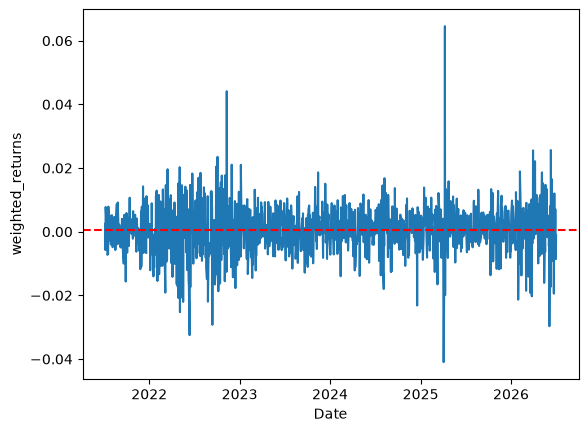

In [8]:
sns.lineplot(data = weighted_returns_df, x = 'Date', y = 'weighted_returns')
plt.axhline(y=weighted_returns_df['weighted_returns'].mean(), color='red', linestyle='--')

## Time-Based Rebalancing Strategy

In [9]:
## REBALANCING QUARTERLY BASED ON SHARPE RATIO ##
import importlib
import src.config as config

importlib.reload(config)

asset_class_caps = config.asset_class_caps
portfolio_groups = config.portfolio_groups
asset_bounds = config.asset_bounds

from src.optimization import build_constraints
tb_portfolio = long_data.copy()
port_start = tb_portfolio['Date'].iloc[0]
port_end = tb_portfolio['Date'].iloc[-1]

In [10]:
tickers = daily_returns.columns

constraints = build_constraints(
    tickers,
    config.portfolio_groups,
    config.asset_class_caps
)

bounds = tuple(asset_bounds for _ in range(len(tickers)))

initial_weights = {
    "SPY": 0.10,
    "QQQ": 0.08,
    "IWM": 0.07,
    "EFA": 0.08,
    "EEM": 0.07,
    "AGG": 0.10,
    "TLT": 0.08,
    "LQD": 0.07,
    "GLD": 0.075,
    "VNQ": 0.075,
    "MTUM": 0.04,
    "VLUE": 0.04,
    "QUAL": 0.035,
    "USMV": 0.035
}

initial = pd.Series(initial_weights).reindex(daily_returns.columns).values

In [11]:
test = tb_portfolio.loc[tb_portfolio['Date'] == '2021-12-31', 'weighted_returns']
20 / test

124     -3.803647e+05
1377             -inf
2630    -1.500176e+05
3883     1.951718e+04
5136             -inf
6389    -1.327309e+05
7642    -1.350897e+05
8895    -2.135101e+04
10148            -inf
11401   -7.935881e+04
12654             inf
13907            -inf
15160   -1.217904e+05
16413             inf
Name: weighted_returns, dtype: float64

In [12]:
## Function for evaluating by date ## 
## Period Weights to be an asset indexed series of predetermined weights ##
## df will be a time-series of portfolio return data ## 
def evaluate_period(start_date, end_date, period_weights, df):
    eval_data = df[df['Date'].between(start_date, end_date)].copy()

    eval_data['weights'] = eval_data['Asset'].map(period_weights)
    eval_data['weighted_returns'] = eval_data['weights'] * eval_data['Return']
    daily_rfr = pd.Series(eval_data.groupby('Date')['daily_rfr'].mean()).values

    daily_portfolio = (
        eval_data
        .groupby('Date', as_index=False)['weighted_returns']
        .sum()
        .rename(columns={'weighted_returns': 'portfolio_return'})
    )
    daily_portfolio['rf_rate'] = daily_rfr
    daily_portfolio['portfolio_value'] = (
    1 + daily_portfolio['portfolio_return']
    ).cumprod()

    daily_portfolio['running_peak'] = daily_portfolio['portfolio_value'].cummax()

    daily_portfolio['drawdown'] = (
        daily_portfolio['portfolio_value'] / daily_portfolio['running_peak'] - 1
    )

    summary = {
        'start_date': start_date,
        'end_date': end_date,
        'period_return': daily_portfolio['portfolio_value'].iloc[-1] - 1,
        'volatility': daily_portfolio['portfolio_return'].std() * np.sqrt(252),
        'max_drawdown': daily_portfolio['drawdown'].min(),
        'avg_daily_return': daily_portfolio['portfolio_return'].mean()
    }

    asset_growth = (
        eval_data
        .sort_values(['Asset', 'Date'])
        .groupby('Asset')['Return']
        .apply(lambda x: (1 + x).prod())
    )

    end_values = period_weights * asset_growth
    end_weights = end_values / end_values.sum()

    return daily_portfolio, summary, end_weights


In [13]:
def optimizer(df, start_date, end_date):

    opt_df = df[df['Date'].between(start_date, end_date)].copy()

    rf = opt_df['daily_rfr'].mean()

    returns = (
        opt_df.pivot(index = 'Date', columns = 'Asset', values = 'Return')
        )
    returns_mean = returns.mean()
    returns_cov = returns.cov()
    
    optimized = sco.minimize(
    negative_sharpe,
    initial, 
    args = (returns_mean, returns_cov, rf),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
    )
    
    return pd.Series(optimized.x, index=returns.columns)

In [14]:
def build_evaluation_schedule(df, date_col='Date', freq='Q', lookback_obs=252, min_obs=63):
    dates = (
        pd.to_datetime(df[date_col])
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    port_start = dates.iloc[0]
    port_end = dates.iloc[-1]

    if freq == 'Q':
        hold_starts = pd.date_range(
            port_start.to_period('Q').start_time,
            port_end,
            freq='QS'
        )
        offset = pd.offsets.QuarterEnd(0)

    elif freq == 'Y':
        hold_starts = pd.date_range(
            port_start.to_period('Y').start_time,
            port_end,
            freq='YS'
        )
        offset = pd.offsets.YearEnd(0)

    rows = []

    for hold_start in hold_starts:
        hold_end = min(hold_start + offset, port_end)

        available_est_dates = dates[dates < hold_start]

        if len(available_est_dates) < min_obs:
            continue

        est_dates = available_est_dates.tail(lookback_obs)

        rows.append({
            'est_start': est_dates.iloc[0],
            'est_end': est_dates.iloc[-1],
            'hold_start': hold_start,
            'hold_end': hold_end,
            'est_obs': len(est_dates)
        })

    return pd.DataFrame(rows)

In [15]:
evaluation_schedule_quarterly = build_evaluation_schedule(
    tb_portfolio,
    date_col='Date',
    freq= 'Q',
    lookback_obs=252,
    min_obs=63
)

In [16]:
evaluation_schedule_annual = build_evaluation_schedule(
    tb_portfolio,
    date_col='Date',
    freq = 'Y',
    lookback_obs=252,
)

In [17]:
weights_2021 = pd.Series(weight_list, index = daily_returns.columns)

In [18]:
## Annual Evaluation
daily_2021, summary_2021, x = evaluate_period(
    start_date = port_start,
    end_date = '2021-12-31',
    period_weights=weights_2021,
    df = tb_portfolio)

In [19]:
## Annual Evaluation ##
eval_results_annual = []
daily_periods_annual = [daily_2021]
eval_results_annual.append(summary_2021)

for _, period in evaluation_schedule_annual.iterrows():

    weights = optimizer(
        df = tb_portfolio,
        start_date = period['est_start'],
        end_date = period['est_end']
    )

    daily, summary, _ = evaluate_period(
    start_date = period['hold_start'],
    end_date = period['hold_end'],
    period_weights=weights,
    df = tb_portfolio
    )

    summary['est_start'] = period['est_start']
    summary['est_end'] = period['est_end']
    summary['hold_start'] = period['hold_start']
    summary['hold_end'] = period['hold_end']
    summary['est_obs'] = period['est_obs']

    eval_results_annual.append(summary)
    daily_periods_annual.append(daily)

rebalanced_annually = (
    pd.concat(daily_periods_annual)
    .sort_values('Date')
    .reset_index(drop=True)
)

rebalanced_annually['portfolio_value'] = (
    1 + rebalanced_annually['portfolio_return']
).cumprod()

results_df_annual = pd.DataFrame(eval_results_annual)


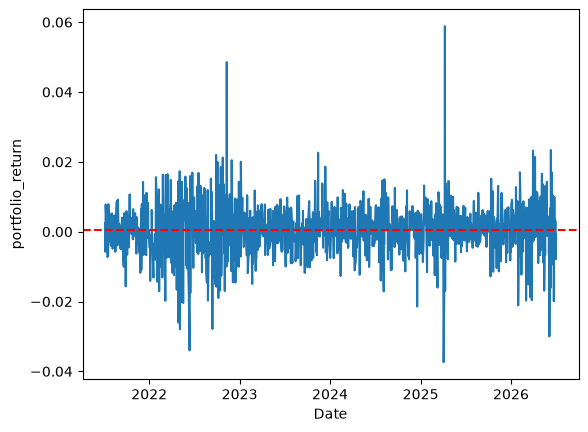

In [20]:
sns.lineplot(data = rebalanced_annually, x = 'Date', y = 'portfolio_return')
plt.axhline(y=rebalanced_annually['portfolio_return'].mean(), color='red', linestyle='--')

In [21]:
Q1_daily, Q1_summary = evaluate_period(
    start_date = port_start,
    end_date = '2021-12-31',
    period_weights=weights_2021,
    df = tb_portfolio)

ValueError: too many values to unpack (expected 2, got 3)

In [ ]:
## Quarterly Evaluation ##
eval_results_quarterly = []
daily_periods_quarterly = [Q1_daily]
eval_results_quarterly.append(Q1_summary)

for _, period in evaluation_schedule_quarterly.iterrows():

    weights = optimizer(
        df=tb_portfolio,
        start_date=period['est_start'],
        end_date=period['est_end']
    )

    daily, summary, _ = evaluate_period(
        start_date=period['hold_start'],
        end_date=period['hold_end'],
        period_weights=weights,
        df=tb_portfolio
    )

    summary['est_start'] = period['est_start']
    summary['est_end'] = period['est_end']
    summary['hold_start'] = period['hold_start']
    summary['hold_end'] = period['hold_end']
    summary['est_obs'] = period['est_obs']

    eval_results_quarterly.append(summary)
    daily_periods_quarterly.append(daily)

rebalanced_quarterly = (
    pd.concat(daily_periods_quarterly)
    .sort_values('Date')
    .reset_index(drop=True)
)

rebalanced_quarterly['portfolio_value'] = (
    1 + rebalanced_quarterly['portfolio_return']
).cumprod()

results_df_quarterly = pd.DataFrame(eval_results_quarterly)

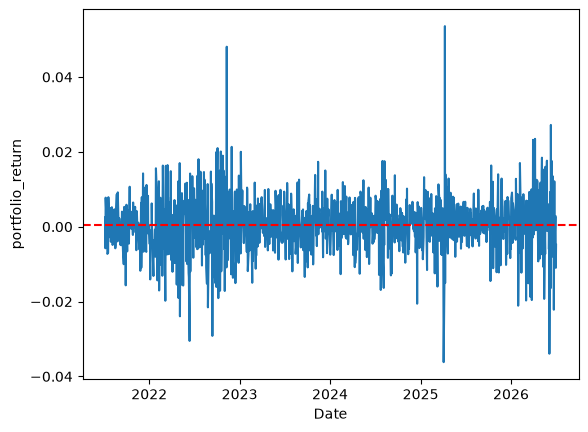

In [ ]:
sns.lineplot(data = rebalanced_quarterly, x = 'Date', y = 'portfolio_return')
plt.axhline(y=rebalanced_quarterly['portfolio_return'].mean(), color='red', linestyle='--')

## Band-Based Rebalancing Strategy

In [ ]:
eval_results_quarterly_band = []
daily_periods_quarterly_band = [Q1_daily]
eval_results_quarterly_band.append(Q1_summary)

band = 0.16
current_weights = weights_2021.copy()

for _, period in evaluation_schedule_quarterly.iterrows():

    daily, summary, ending_weights = evaluate_period(
        start_date=period['hold_start'],
        end_date=period['hold_end'],
        period_weights=current_weights,
        df=tb_portfolio
    )

    rebalance_needed = (ending_weights > band).any()

    summary['est_start'] = period['est_start']
    summary['est_end'] = period['est_end']
    summary['hold_start'] = period['hold_start']
    summary['hold_end'] = period['hold_end']
    summary['est_obs'] = period['est_obs']
    summary['rebalanced'] = rebalance_needed

    eval_results_quarterly.append(summary)
    daily_periods_quarterly.append(daily)

    if rebalance_needed:
        print(f"Rebalance at: {period['hold_end']}")

        current_weights = optimizer(
        df=tb_portfolio,
        start_date=period['est_start'],
        end_date=period['est_end']
        )
    else:
        current_weights = ending_weights.copy() 

rebalanced_quarterly_band = (
    pd.concat(daily_periods_quarterly_band)
    .sort_values('Date')
    .reset_index(drop=True)
)

rebalanced_quarterly_band['portfolio_value'] = (
    1 + rebalanced_quarterly_band['portfolio_return']
).cumprod()

results_df_quarterly_band = pd.DataFrame(eval_results_quarterly_band)

Rebalance at: 2022-03-31 00:00:00
Rebalance at: 2022-06-30 00:00:00
Rebalance at: 2023-03-31 00:00:00
Rebalance at: 2024-09-30 00:00:00
Rebalance at: 2025-03-31 00:00:00
Rebalance at: 2025-06-30 00:00:00
Rebalance at: 2025-09-30 00:00:00
Rebalance at: 2025-12-31 00:00:00
Rebalance at: 2026-03-31 00:00:00
Rebalance at: 2026-06-30 00:00:00


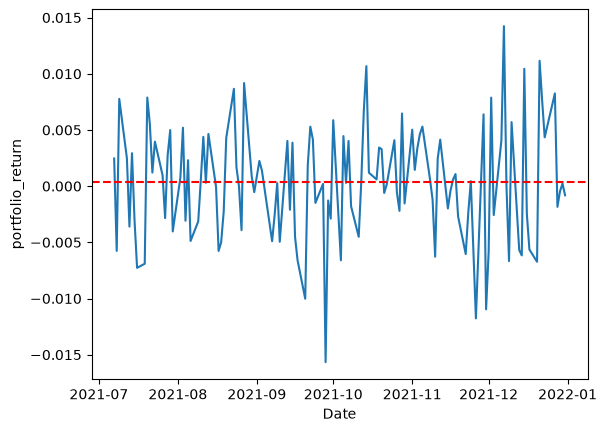

In [ ]:
sns.lineplot(data = rebalanced_quarterly_band, x = 'Date', y = 'portfolio_return')
plt.axhline(y=rebalanced_quarterly_band['portfolio_return'].mean(), color='red', linestyle='--')